# BB84 Quantum Key Distribution — Simulation

BB84 (Bennett & Brassard, 1984) is the first quantum cryptographic protocol.
It lets two parties (Alice and Bob) establish a shared secret key over a public
channel, with any eavesdropper being *detectable* through increased error rates.

This notebook simulates BB84 classically to demonstrate:
- The sifting process (basis reconciliation)
- How channel noise affects key quality (QBER)
- How an eavesdropper (Eve) is detected via a QBER spike


In [52]:
import numpy as np
import matplotlib.pyplot as plt

## 🧠 Key Idea

BB84 is not about hiding information—it is about **detecting disturbance**.

- Measurement in quantum systems is irreversible  
- An eavesdropper must guess a basis  
- Incorrect guesses introduce **detectable errors**

👉 Security emerges statistically, not deterministically.

In [53]:
def generate_bits(n):
    return np.random.randint(0, 2, n)

def generate_bases(n):
    return np.random.randint(0, 2, n)  # 0 = Z, 1 = X

def measure(qubit, basis):
    # Simplified measurement model
    if basis == 0:  # Z basis
        return qubit
    else:  # X basis introduces randomness
        return np.random.randint(0, 2)

## ⚙️ Modeling Approach

This simulation operates at the **bit level**, not full quantum states.

- We approximate measurement behavior probabilistically  
- We do not simulate state vectors or density matrices  
- The goal is to capture **information-theoretic behavior**

👉 This allows us to study large-scale effects like QBER efficiently.

## 🔁 Protocol Flow

1. Alice generates random bits and bases  
2. Bob measures using random bases  
3. Basis mismatch introduces randomness  
4. Matching bases produce the sifted key  
5. Errors are measured using QBER

👉 Only ~50% of bits survive basis reconciliation

## 🔎 Small Example (n = 10)

Before running large simulations, we walk through a small example to visualize how BB84 works step-by-step.

This helps verify:
- basis matching  
- sifting  
- error calculation  

👉 You should be able to manually check this table.

In [54]:
import pandas as pd

def bb84_trace(n=10):
    alice_bits = generate_bits(n)
    alice_bases = generate_bases(n)
    bob_bases = generate_bases(n)

    bob_results = []
    for i in range(n):
        if bob_bases[i] == alice_bases[i]:
            bob_results.append(alice_bits[i])
        else:
            bob_results.append(np.random.randint(0, 2))

    sift_mask = alice_bases == bob_bases

    df = pd.DataFrame({
        "Index": np.arange(n),
        "Alice Bit": alice_bits,
        "Alice Basis (0=Z,1=X)": alice_bases,
        "Bob Basis (0=Z,1=X)": bob_bases,
        "Bob Result": bob_results,
        "Keep?": sift_mask
    })

    return df

trace_df = bb84_trace(10)
trace_df

,Index,Alice Bit,"Alice Basis (0=Z,1=X)","Bob Basis (0=Z,1=X)",Bob Result,Keep?
0,0,0,1,0,0,False
1,1,1,0,0,1,True
2,2,1,0,0,1,True
3,3,1,0,0,1,True
4,4,0,0,1,0,False
5,5,1,1,0,0,False
6,6,1,0,1,1,False
7,7,0,1,0,1,False
8,8,1,0,1,1,False
9,9,1,0,0,1,True


### 🧠 How to read this table

- Rows where bases match → kept (True)
- Rows where bases differ → discarded
- Compare "Alice Bit" vs "Bob Result" only for kept rows

👉 This is the sifted key

In [55]:
# Extract sifted keys
sifted = trace_df[trace_df["Keep?"] == True]

print("Alice Key:", list(sifted["Alice Bit"]))
print("Bob Key:  ", list(sifted["Bob Result"]))

Alice Key: [1, 1, 1, 1]
Bob Key:   [1, 1, 1, 1]


In [56]:
def bb84(n, noise_prob=0.0, noise_type="bitflip", eve=False):
    # Alice
    alice_bits = generate_bits(n)
    alice_bases = generate_bases(n)

    # Eve (Intercept-Resend)
    if eve:
        eve_bases = generate_bases(n)
        eve_results = []
        for i in range(n):
            eve_results.append(measure(alice_bits[i], eve_bases[i]))
        transmitted_bits = eve_results
    else:
        transmitted_bits = alice_bits.copy()

    # Noise
    noisy_bits = []

    for bit in transmitted_bits:
        if np.random.rand() < noise_prob:
            if noise_type == "bitflip":
                noisy_bits.append(1 - bit)
            elif noise_type == "depolarizing":
                # simulate disturbance relative to measurement basis
                if np.random.rand() < 0.5:
                    noisy_bits.append(1 - bit)  # error
                else:
                    noisy_bits.append(bit)      # no error
        else:
            noisy_bits.append(bit)

    # Bob
    bob_bases = generate_bases(n)
    bob_results = []

    for i in range(n):
        if bob_bases[i] == alice_bases[i]:
            bob_results.append(noisy_bits[i])
        else:
            bob_results.append(measure(noisy_bits[i], bob_bases[i]))

    # Sifting
    sifted_key_alice = []
    sifted_key_bob = []

    for i in range(n):
        if alice_bases[i] == bob_bases[i]:
            sifted_key_alice.append(alice_bits[i])
            sifted_key_bob.append(bob_results[i])

    # QBER Calculation
    errors = sum(a != b for a, b in zip(sifted_key_alice, sifted_key_bob))
    qber = errors / len(sifted_key_alice) if len(sifted_key_alice) > 0 else 0

    return qber, len(sifted_key_alice)

## 📊 Quantum Bit Error Rate (QBER)

QBER measures the fraction of mismatched bits between Alice and Bob after sifting.

- Low QBER → channel likely secure  
- High QBER → presence of noise or eavesdropping  

👉 Security decisions are based on **thresholds**, not individual bits

In [57]:
qber, key_len = bb84(1000)

print("QBER:", qber)
print("Sifted Key Length:", key_len)

QBER: 0.0
Sifted Key Length: 486


## 🌫️ Noise Models

We simulate two types of noise:

### 1. Bit-Flip Noise
- Flips 0 ↔ 1 deterministically  
- Represents structured, worst-case errors  

### 2. Depolarizing Noise
- Produces random outcomes  
- Represents maximum uncertainty  

👉 These models help us understand how different noise types impact detectability

In [58]:
noise_levels = np.linspace(0, 0.2, 10)
qber_values = []

for noise in noise_levels:
    qber, _ = bb84(3000, noise_prob=noise)
    qber_values.append(qber)

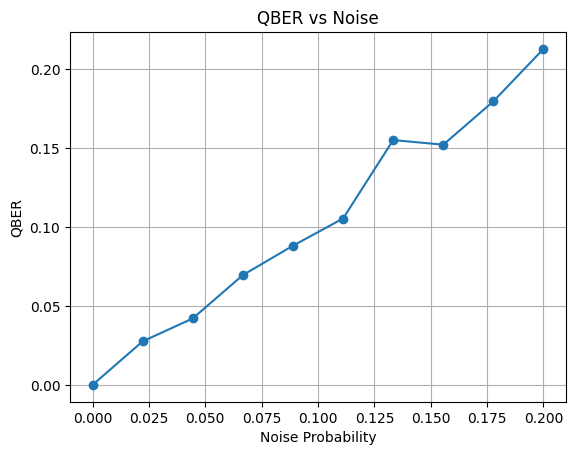

In [59]:
plt.figure()
plt.plot(noise_levels, qber_values, marker='o')
plt.xlabel("Noise Probability")
plt.ylabel("QBER")
plt.title("QBER vs Noise")
plt.grid()
plt.show()

## 🔍 Insight: Not All Noise Is Equal

Observed behavior:

- Bit-flip noise produces higher QBER  
- Depolarizing noise produces lower QBER  

### Why?

- Bit-flip → always introduces an error when triggered  
- Depolarizing → produces random outcomes (≈50% error rate)

👉 Result:
**Structured noise is more detectable than random noise**

---

### 🧠 Deeper Interpretation

- BB84 is highly sensitive to **correlated disturbances**
- Fully random noise can partially "hide" itself
- This creates ambiguity between:
  - natural noise  
  - adversarial interference  

👉 Security depends on statistical thresholds, not perfect detection

## 🕵️ Eavesdropping (Intercept-Resend)

We simulate an adversary (Eve) who:

- Measures qubits using random bases  
- Resends the measured state to Bob  

This introduces **irreversible disturbance** when the wrong basis is used.

👉 Eve’s presence increases QBER

In [60]:
qber_no_eve, _ = bb84(3000, noise_prob=0.02, eve=False)
qber_eve, _ = bb84(3000, noise_prob=0.02, eve=True)

print("QBER without Eve:", qber_no_eve)
print("QBER with Eve:", qber_eve)

QBER without Eve: 0.01929474384564205
QBER with Eve: 0.2536813922356091


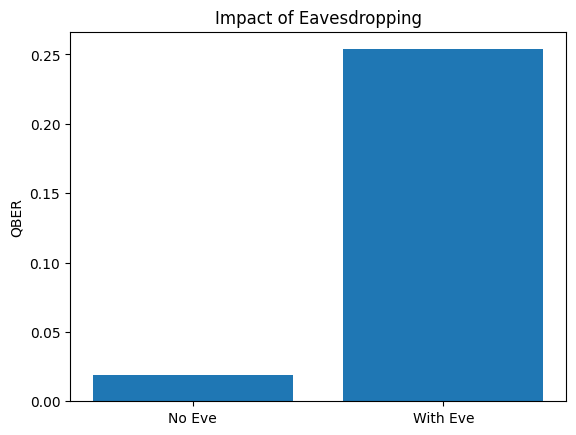

In [61]:
labels = ["No Eve", "With Eve"]
values = [qber_no_eve, qber_eve]

plt.figure()
plt.bar(labels, values)
plt.ylabel("QBER")
plt.title("Impact of Eavesdropping")
plt.show()

## ⚡ Systems Insight

At small scales:
- Noise and eavesdropping look similar  

At larger scales:
- Statistical patterns emerge  
- QBER increases detectably  

👉 BB84 operates in a **statistical detection regime**, not a deterministic one

In [62]:
def run_trials(trials=20, n=2000, noise=0.02, eve=False):
    results = []
    for _ in range(trials):
        qber, _ = bb84(n, noise_prob=noise, eve=eve)
        results.append(qber)
    return np.mean(results), np.std(results)

mean_no_eve, std_no_eve = run_trials(eve=False)
mean_eve, std_eve = run_trials(eve=True)

print("No Eve -> Mean:", mean_no_eve, "Std:", std_no_eve)
print("With Eve -> Mean:", mean_eve, "Std:", std_eve)

No Eve -> Mean: 0.02126960773494065 Std: 0.003965599231948683
With Eve -> Mean: 0.2653915977152768 Std: 0.005996265893164704


In [63]:
noise_levels = np.linspace(0, 0.2, 10)

qber_bitflip = []
qber_depolarizing = []

for noise in noise_levels:
    q1, _ = bb84(3000, noise_prob=noise, noise_type="bitflip")
    q2, _ = bb84(3000, noise_prob=noise, noise_type="depolarizing")
    
    qber_bitflip.append(q1)
    qber_depolarizing.append(q2)

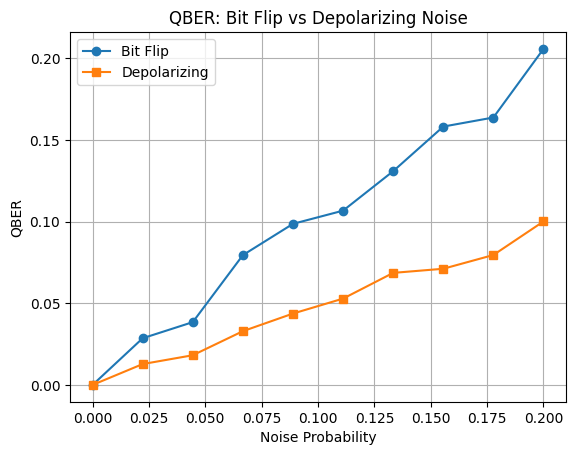

In [64]:
plt.figure()

plt.plot(noise_levels, qber_bitflip, marker='o', label="Bit Flip")
plt.plot(noise_levels, qber_depolarizing, marker='s', label="Depolarizing")

plt.xlabel("Noise Probability")
plt.ylabel("QBER")
plt.title("QBER: Bit Flip vs Depolarizing Noise")
plt.legend()
plt.grid()

plt.show()

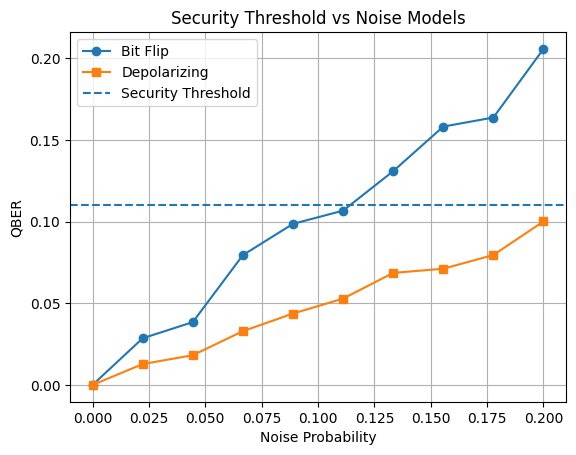

In [65]:
threshold = 0.11  # typical BB84 security threshold

plt.figure()
plt.plot(noise_levels, qber_bitflip, marker='o', label="Bit Flip")
plt.plot(noise_levels, qber_depolarizing, marker='s', label="Depolarizing")

plt.axhline(y=threshold, linestyle='--', label="Security Threshold")

plt.xlabel("Noise Probability")
plt.ylabel("QBER")
plt.title("Security Threshold vs Noise Models")
plt.legend()
plt.grid()
plt.show()

## 🚀 What This Reveals

- BB84 is a **statistical security protocol**
- Noise and adversaries both act as **error channels**
- Detectability depends on **error structure, not just magnitude**

---

## 🤔 Open Questions

- Can random noise mask adversarial behavior?
- What QBER thresholds are practical in real systems?
- How does this extend to coherent attacks?

---

